## Prepare the inputs to the unfolding which use the actual data instead of MC

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import sys
import localSettings as ls
import math
print(ls.main_path)
import load_data_run123
import plotter_alex
import importlib
importlib.reload(plotter_alex)
import uproot
import matplotlib.pylab as pylab
import numpy as np
import math
from sklearn.model_selection import train_test_split
import pickle
import xgboost as xgb
import nue_booster 
importlib.reload(nue_booster)
import awkward
from matplotlib import gridspec
from collections import defaultdict
import ROOT
from ROOT import TFile
from ROOT import TCanvas, TFile, TProfile, TNtuple, TH1F, TH2F
from ROOT import gROOT, gBenchmark, gRandom, gSystem
import csv

/home/alex/NuMI/PELEE/
Welcome to JupyROOT 6.24/02


In [2]:
ending = "Jan19b"
ending_nob = "Jan19"

## The Smearcept Matrix

This matrix will be the one created entirely from the MC

i.e. full_500_catsel_nopions_recoE_usingSelection_smearcept_weighted_blockwise_recoCut_"+ending+".csv

## Prior Truth

This is still an MC estimate of the prior truth

i.e. nue_full_500_catsel_nopions_recoE_usingSelection_prior_true_signal_blockwise_recoCut_comb_"+ending+".csv

## Data Signal

This should be data - selected backgrounds (MC+EXT)

First, load in the data signal

In [3]:
#Nue Run1

nue_data_vars_tot_df = pd.read_csv("nue_data_varstot_full_catsel_nopions_recoE_usingSelection_recoCut_"+ending_nob+".csv")
nue_data_weights_tot_df = pd.read_csv("nue_data_weightstot_full_catsel_nopions_recoE_usingSelection_recoCut_"+ending_nob+".csv")


nue_data_vars_tot = defaultdict(list)
nue_data_weights_tot = defaultdict(list)


nue_data_vars_tot_run1 = nue_data_vars_tot_df.to_dict()
nue_data_weights_tot_run1 = nue_data_weights_tot_df.to_dict()
nue_data_vars_tot_run1.pop("Unnamed: 0")
nue_data_weights_tot_run1.pop("Unnamed: 0")


#Numu Run1

numu_data_vars_tot_df = pd.read_csv("numu_data_varstot_full_catsel_nopions_recoE_usingSelection_recoCut_"+ending_nob+".csv")
numu_data_weights_tot_df = pd.read_csv("numu_data_weightstot_full_catsel_nopions_recoE_usingSelection_recoCut_"+ending_nob+".csv")

numu_data_vars_tot = defaultdict(list)
numu_data_weights_tot = defaultdict(list)


numu_data_vars_tot_run1 = numu_data_vars_tot_df.to_dict()
numu_data_weights_tot_run1 = numu_data_weights_tot_df.to_dict()
numu_data_vars_tot_run1.pop("Unnamed: 0")
numu_data_weights_tot_run1.pop("Unnamed: 0")


#Nue Run3

nue_data_vars_tot_df = pd.read_csv("nue_data_varstot_full_catsel_nopions_recoE_usingSelection_recoCut_run3_"+ending_nob+".csv")
nue_data_weights_tot_df = pd.read_csv("nue_data_weightstot_full_catsel_nopions_recoE_usingSelection_recoCut_run3_"+ending_nob+".csv")


nue_data_vars_tot = defaultdict(list)
nue_data_weights_tot = defaultdict(list)


nue_data_vars_tot_run3 = nue_data_vars_tot_df.to_dict()
nue_data_weights_tot_run3 = nue_data_weights_tot_df.to_dict()
nue_data_vars_tot_run3.pop("Unnamed: 0")
nue_data_weights_tot_run3.pop("Unnamed: 0")


#Numu Run3

numu_data_vars_tot_df = pd.read_csv("numu_data_varstot_full_catsel_nopions_recoE_usingSelection_recoCut_run3_"+ending_nob+".csv")
numu_data_weights_tot_df = pd.read_csv("numu_data_weightstot_full_catsel_nopions_recoE_usingSelection_recoCut_run3_"+ending_nob+".csv")

numu_data_vars_tot = defaultdict(list)
numu_data_weights_tot = defaultdict(list)


numu_data_vars_tot_run3 = numu_data_vars_tot_df.to_dict()
numu_data_weights_tot_run3 = numu_data_weights_tot_df.to_dict()
numu_data_vars_tot_run3.pop("Unnamed: 0")
numu_data_weights_tot_run3.pop("Unnamed: 0")

{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5}

In [4]:
#Add each of the runs together

i = 0
nue_data_var = []
nue_data_weight = []
numu_data_var = []
numu_data_weight = []

while i < 6:  
    nue_data_var.append(nue_data_vars_tot_run1[str(0)][i] + nue_data_vars_tot_run3[str(0)][i])
    nue_data_weight.append(nue_data_weights_tot_run1[str(0)][i] + nue_data_weights_tot_run3[str(0)][i])
    numu_data_var.append(numu_data_vars_tot_run1[str(0)][i] + numu_data_vars_tot_run3[str(0)][i])
    numu_data_weight.append(numu_data_weights_tot_run1[str(0)][i] + numu_data_weights_tot_run3[str(0)][i])
    i=i+1

In [5]:
#Now append nue to numu

nue_numu_data_vars_tot = np.concatenate((nue_data_var, numu_data_var), axis=0)
nue_numu_data_weights_tot = np.concatenate((nue_data_weight, numu_data_weight), axis=0)

In [6]:
nue_numu_data_vars_tot

array([ 62, 104,  35,  13,   6,   2,  27, 822, 759, 302, 143,  80])

In [7]:
# Now need the selected backgrounds (MC + EXT)

nue_MC_EXT_bkg = pd.read_csv("nue_nopions_energy_usingSelection_comb_cv_nue_bkg_incExt_"+ending+".csv", header=None)
nue_MC_EXT_bkg = nue_MC_EXT_bkg.values[:, 0]

numu_MC_EXT_bkg = pd.read_csv("numu_nopions_energy_usingSelection_comb_cv_numu_bkg_incExt_"+ending+".csv", header=None)
numu_MC_EXT_bkg = numu_MC_EXT_bkg.values[:, 0]

In [8]:
nue_numu_MC_bkg_tot = np.concatenate((nue_MC_EXT_bkg, numu_MC_EXT_bkg), axis=0)

print(nue_numu_MC_bkg_tot)

[ 18.76664423  37.45086691  13.30547888   7.30978266   1.92115632
   2.9030358   11.81627631 285.60108619 269.63682435 135.03843215
  55.72084381  36.21829598]


In [9]:
data_signal = nue_numu_data_vars_tot - nue_numu_MC_bkg_tot

No handles with labels found to put in legend.


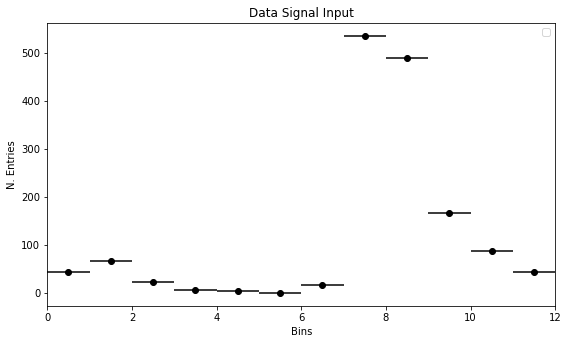

In [10]:
allsel_fig = plt.figure(figsize=(8, 7))
allsel_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
allsel_ax1 = plt.subplot(allsel_gs[0])

allsel_ax1.set_xlim([0, 12])    #TrueE, lepton mom
current_bincenters =  np.arange(0.5, 12.5, 1)
current_bin_size = 1

allsel_ax1.errorbar(
            current_bincenters,
            data_signal,
            xerr=current_bin_size/2,
            #yerr=nue_data_weight,
            fmt='ko')

plt.title("Data Signal Input")
plt.xlabel("Bins")
plt.ylabel("N. Entries")
plt.legend()
plt.tight_layout()

ending = "Jan19b_Data"
allsel_fig.savefig("data_signal_input_energy_"+ending+".svg", bbox_inches='tight')

In [11]:
ending = "Jan19b_Data"

In [12]:
np.savetxt("nue_full_500_catsel_nopions_recoE_usingSelection_data_signal_MCONLY_blockwise_recoCut_comb_"+ending+".csv", 
           data_signal,
           delimiter =", ", 
           fmt ='% s')  

## The covariance matrix

This now needs to contain...
- The statistical uncertainty on the data (before bkg subtraction)
- The statitsical uncertainty on the backgrounds
- The POT counting uncertainty
- The dirt systematic uncertaity
- The detector systematic uncertainties
- The ppfx, genie, reint, and geosim systematic uncertainties

In [13]:
## Stat uncertaintiy on the data is just sqrt(N)

cov_data_stat  = np.zeros([len(nue_numu_data_vars_tot), len(nue_numu_data_vars_tot)])

stat_unc_data = np.sqrt(nue_numu_data_vars_tot)

#the full number goes into the cov matrix, not the root
cov_data_stat[np.diag_indices_from(cov_data_stat)]   = nue_numu_data_vars_tot
print("cov_data_stat = ", np.diag(cov_data_stat))

cov_data_stat =  [ 62. 104.  35.  13.   6.   2.  27. 822. 759. 302. 143.  80.]


In [14]:
###Load in a cov matrix with all of the other uncertainties
#ending = "Jan19b_Data"

cov_matrix = pd.read_csv("full_500_catsel_nopions_recoE_usingSelection_data_covmat_blockwise_recoCut_comb_"+ending+".csv", header=None)

cov_matrix  = cov_matrix.values
print(cov_matrix)

[[ 5.12545629e+01  7.66870488e+01  2.15293878e+01  6.85644212e+00
   1.00285034e+00 -1.61029428e+00  9.21513744e+01  3.94453592e+02
   2.69421050e+01  5.96140715e+01  4.25412856e+01  2.21269772e+01]
 [ 7.66870488e+01  4.22099253e+02  1.93574254e+02  5.50965653e+01
   2.03099665e+01  2.22427844e+01 -7.23125399e+01  1.29391192e+02
   5.14356995e+02  2.29092535e+02  5.93196984e+01  4.33915259e+01]
 [ 2.15293878e+01  1.93574254e+02  1.50974234e+02  3.66835345e+01
   1.52097044e+01  1.96919542e+01 -1.56982922e+02 -3.65340549e+02
   2.97897268e+02  6.13866949e+01 -1.85657579e+01  2.90439876e+00]
 [ 6.85644212e+00  5.50965653e+01  3.66835345e+01  1.38006857e+01
   4.42046346e+00  5.83470209e+00 -4.36743536e+01 -5.93290005e+01
   1.47738300e+02  5.00247584e+01  7.21174066e+00  8.93645910e+00]
 [ 1.00285034e+00  2.03099665e+01  1.52097044e+01  4.42046346e+00
   2.29677037e+00  2.56299336e+00 -2.38896257e+01 -5.66074956e+01
   4.61808024e+01  1.00513805e+01 -2.29064330e+00  6.00504395e-01]
 [-1.

In [15]:
total_input_cov_matrix = cov_matrix + cov_data_stat

In [16]:
total_input_cov_matrix

array([[ 1.13254563e+02,  7.66870488e+01,  2.15293878e+01,
         6.85644212e+00,  1.00285034e+00, -1.61029428e+00,
         9.21513744e+01,  3.94453592e+02,  2.69421050e+01,
         5.96140715e+01,  4.25412856e+01,  2.21269772e+01],
       [ 7.66870488e+01,  5.26099253e+02,  1.93574254e+02,
         5.50965653e+01,  2.03099665e+01,  2.22427844e+01,
        -7.23125399e+01,  1.29391192e+02,  5.14356995e+02,
         2.29092535e+02,  5.93196984e+01,  4.33915259e+01],
       [ 2.15293878e+01,  1.93574254e+02,  1.85974234e+02,
         3.66835345e+01,  1.52097044e+01,  1.96919542e+01,
        -1.56982922e+02, -3.65340549e+02,  2.97897268e+02,
         6.13866949e+01, -1.85657579e+01,  2.90439876e+00],
       [ 6.85644212e+00,  5.50965653e+01,  3.66835345e+01,
         2.68006857e+01,  4.42046346e+00,  5.83470209e+00,
        -4.36743536e+01, -5.93290005e+01,  1.47738300e+02,
         5.00247584e+01,  7.21174066e+00,  8.93645910e+00],
       [ 1.00285034e+00,  2.03099665e+01,  1.5209704

In [17]:
np.savetxt("full_500_catsel_nopions_recoE_usingSelection_data_covmat_blockwise_recoCut_comb_datainput_"+ending+".csv", 
               total_input_cov_matrix,
               delimiter =", ", 
               fmt ='% s') 

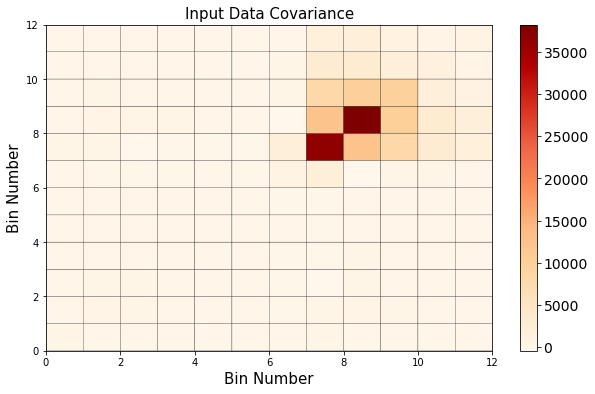

In [18]:
fig = plt.figure(figsize=(10, 6))  
    
bins = np.arange(0, 13, 1)
    
plt.pcolor(bins, bins, total_input_cov_matrix, cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)
            
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)
#cbar.set_label(r"Log (Power)", size=15)

plt.xlabel('Bin Number', fontsize=15)
plt.ylabel('Bin Number', fontsize=15)

plt.title('Input Data Covariance', fontsize=15)

plt.show()

fig.savefig("data_cov_input_energy_"+ending+".svg",bbox_inches='tight' )